In [1]:
import numpy as np
from sklearn.neighbors import KDTree
from sklearn import datasets
from sklearn.decomposition import PCA
from collections import Counter
import matplotlib.pyplot as plt
import time

def accuracy_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    correct = np.sum(y_true == y_pred)
    return correct / len(y_true)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def distp(X,C): #lab7
    LpunktowX = X.shape[0]
    LpunktowC = C.shape[0]

    o = np.zeros((LpunktowX,LpunktowC)) 

    for i in range(LpunktowX):
        for j in range(LpunktowC):
            r = X[i]-C[j] #roznica
            o[i,j] = np.sqrt(np.dot(r,r.T))
    return o

class algorytm:
    def __init__(self, n_neighbors=1, use_KD_tree=False):
        self.n_neighbors = n_neighbors
        self.use_KD_tree = use_KD_tree  

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        if self.use_KD_tree:  
            self.tree = KDTree(self.X_train)

    def predict(self, X):
        X = np.array(X)
        predictions = []
        for x in X:
            if self.use_KD_tree:
                dists, idxs = self.tree.query([x], k=self.n_neighbors)
                neighbors = self.y_train[idxs[0]]
            else:
                dists = distp(np.array([x]), self.X_train)[0]
                idxs = np.argsort(dists)[:self.n_neighbors]
                neighbors = self.y_train[idxs]

            if self._is_classification():
                pred = Counter(neighbors).most_common(1)[0][0]
            else:
                pred = np.mean(neighbors)
            predictions.append(pred)
        return np.array(predictions)

    def _is_classification(self):
        return np.issubdtype(self.y_train.dtype, np.integer)
    
    def score(self, X, y):
        preds = self.predict(X)
        if self._is_classification():
            return accuracy_score(y, preds)
        else:
            return mean_squared_error(y, preds)



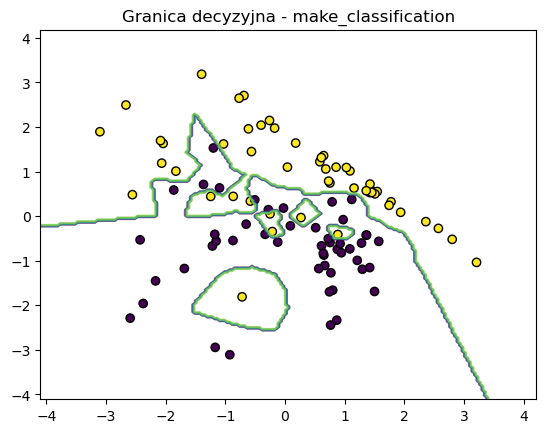

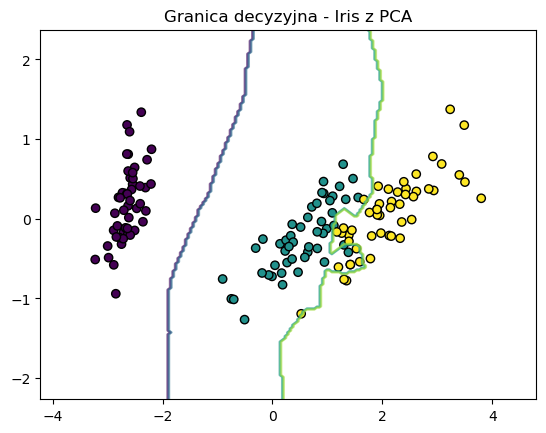

k | Średnia dokładność (Leave-One-Out)
k = 1 | Accuracy = 0.960
k = 2 | Accuracy = 0.960
k = 3 | Accuracy = 0.960
k = 4 | Accuracy = 0.960
k = 5 | Accuracy = 0.967
k = 6 | Accuracy = 0.960
k = 7 | Accuracy = 0.967
k = 8 | Accuracy = 0.967
k = 9 | Accuracy = 0.967
k = 10 | Accuracy = 0.953
Czas klasyczny: 2.4306 s
Czas z KD-Tree: 0.0707 s


In [2]:
#1-3

X, y = datasets.make_classification(n_samples=100, 
                                    n_features=2,
                                    n_informative=2,
                                    n_redundant=0, 
                                    n_repeated=0, 
                                    random_state=3)

model = algorytm(n_neighbors=2)
model.fit(X, y)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid).reshape(xx.shape)

plt.contour(xx, yy, Z, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k')
plt.title("Granica decyzyjna - make_classification")
plt.show()


#4-5
iris = datasets.load_iris()
X_iris, y_iris = iris.data, iris.target

model_iris = algorytm(n_neighbors=2)
model_iris.fit(X_iris, y_iris)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_orig = pca.inverse_transform(grid_pca)
Z = model_iris.predict(grid_orig).reshape(xx.shape)

plt.contour(xx, yy, Z, alpha=0.5)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, edgecolor='k')
plt.title("Granica decyzyjna - Iris z PCA")
plt.show()

#6-7
from sklearn.model_selection import LeaveOneOut

print("k | Średnia dokładność (Leave-One-Out)")
X, y = datasets.load_iris(return_X_y=True)
loo = LeaveOneOut()

for k in range(1, 11):
    correct = 0
    model = algorytm(n_neighbors=k)
    for i in range(len(X)):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)
        X_test = X[i].reshape(1, -1)
        y_test = y[i].reshape(1)

        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        if pred[0] == y_test[0]:
            correct += 1
    acc = correct / len(X)
    print(f"k = {k} | Accuracy = {acc:.3f}")


X, y = datasets.make_classification(n_samples=500, n_features=4, random_state=42)

start = time.time()
model = algorytm(n_neighbors=5, use_KD_tree=False)
model.fit(X, y)
model.predict(X)
end = time.time()
print(f"Czas klasyczny: {end - start:.4f} s")

start = time.time()
model = algorytm(n_neighbors=5, use_KD_tree=True)
model.fit(X, y)
model.predict(X)
end = time.time()
print(f"Czas z KD-Tree: {end - start:.4f} s")